# Notebook 02 - PCA Fault Detection

**Model:** Principal Component Analysis (PCA) -- unsupervised anomaly detection

**Task:** Detect whether a sample deviates from normal plant operation (binary: normal vs. fault). This is **not** multiclass classification -- the model does not identify which fault is occurring, only that something abnormal is happening. Per-fault results reported later are separate binary evaluations (one fault class at a time vs. normal), not a single model distinguishing between fault types.

**Approach:**
1. PCA is fitted on fault-free training data only -- it learns a compact model of what normal operation looks like
2. The number of principal components is selected at the **90% cumulative variance** threshold
3. For any new sample, two statistics are computed to measure deviation from normal:
   - **T2 (Hotelling):** Deviation *within* the PCA subspace -- captures faults that amplify normal operating patterns
   - **Q (SPE):** Reconstruction error -- captures faults that introduce patterns not seen in normal data
4. A sample is classified as faulty if **exceeds the threshold**:  **Q > Q_threshold OR T2 > T2_threshold** (thresholds set at 99% confidence using empirical 99th percentile of fault-free data). 
5. **Consecutive-sample rule:** An alarm is raised and a "run" is classified as faulty only when **6 consecutive samples** all exceed the threshold. Isolated crossings are discarded as noise (Russell et al., 2000)

**How metrics are computed:**
- **FDR, F1, Accuracy** -- computed on **raw threshold crossings** (per-sample). A sample counts as detected if it exceeds the threshold, regardless of the consecutive rule.
- **% Runs Detected, Detection delay** -- computed using the **consecutive rule** (per-run). A run counts as detected only if it produces at least one alarm (6 consecutive exceedances).
- **FPR** -- 2 variants: 1 computed using the **Sample rule** and 1 using **consecutive rule** (practical false alarm rate).

**Data:** Pre-scaled and pre-processed parquets from Notebook 01 (StandardScaler fitted on fault-free training data)

**Fault classes:** 20 fault classes (0 = normal + faults 1--20).

## Section 1 - Data Loading

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_parquet('../data/processed/train_processed.parquet')
test_df  = pd.read_parquet('../data/processed/test_processed.parquet')

meta_cols    = ['faultNumber', 'simulationRun', 'sample']
feature_cols = [c for c in train_df.columns if c not in meta_cols]

print(f'Training: {len(train_df):,} rows x {len(feature_cols)} features')
print(f'Test:     {len(test_df):,} rows x {len(feature_cols)} features')
print(f'Fault classes: {sorted(train_df["faultNumber"].unique())}')

Training: 5,050,000 rows x 48 features
Test:     8,480,000 rows x 48 features
Fault classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


## Section 2 - PCA Components

### 2.1 - Variance Analysis (Scree Plot)

Before choosing how many principal components to retain, we examine how variance is distributed across all components. PCA is fitted on **fault-free training data only** (already StandardScaled from Notebook 01).

- **Scree plot** (left): variance explained by each individual component -- a steep drop-off means a few components capture most of the information
- **Cumulative variance** (right): running total -- we mark the 90%, 95%, and 99% thresholds to see how many components are needed for each level

This guides the choice of `N_COMPONENTS` in the next section.

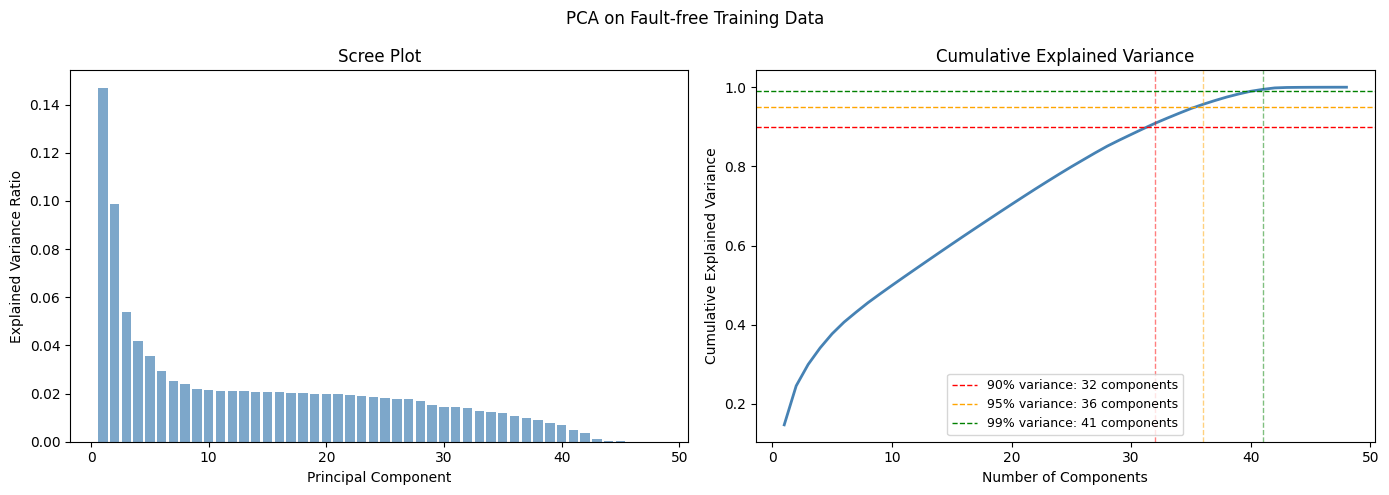

Components to explain 90% variance: 32
Components to explain 95% variance: 36
Components to explain 99% variance: 41
Total features: 48
Dimensionality reduction at 90%: 48 -> 32 (67% of original features)


In [34]:
from sklearn.decomposition import PCA

# Full PCA on fault-free training data
ff_train = train_df[train_df["faultNumber"] == 0][feature_cols].values
_pca_full = PCA().fit(ff_train)
cumvar = np.cumsum(_pca_full.explained_variance_ratio_)

n_90 = int(np.argmax(cumvar >= 0.90)) + 1
n_95 = int(np.argmax(cumvar >= 0.95)) + 1
n_99 = int(np.argmax(cumvar >= 0.99)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(_pca_full.explained_variance_ratio_) + 1),
            _pca_full.explained_variance_ratio_, color="steelblue", alpha=0.7)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")

# Cumulative variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar, color="steelblue", linewidth=2)
for thresh, n, color in [(0.90, n_90, "red"), (0.95, n_95, "orange"), (0.99, n_99, "green")]:
    axes[1].axhline(y=thresh, color=color, linestyle="--", linewidth=1,
                    label=f"{int(thresh*100)}% variance: {n} components")
    axes[1].axvline(x=n, color=color, linestyle="--", linewidth=1, alpha=0.5)
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend(fontsize=9)

plt.suptitle("PCA on Fault-free Training Data", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Components to explain 90% variance: {n_90}")
print(f"Components to explain 95% variance: {n_95}")
print(f"Components to explain 99% variance: {n_99}")
print(f"Total features: {len(feature_cols)}")
print(f"Dimensionality reduction at 90%: {len(feature_cols)} -> {n_90} "
      f"({100*n_90/len(feature_cols):.0f}% of original features)")

### Findings

- 48 features in total (after preprocessing in Notebook 01)
- 32 components explain 90% of variance in normal operation -- a reduction to 67% of the original feature count
- 36 components needed for 95%, 41 for 99% -- the curve flattens gradually with no sharp elbow, indicating variance is spread relatively evenly across many components rather than concentrated in a few
- The scree plot confirms no single dominant component: PC1 explains ~14.5% and PC2 ~9.9%, after which individual contributions drop below 6% and continue declining smoothly

**Component selection:** We use the 90% variance threshold (32 components) as the cutoff for the PCA model in Section 3.

### 2.2 - Model Fitting

Using the variance analysis from Section 2.1, we select N_COMPONENTS at the **90% cumulative variance** threshold and fit the final PCA model on fault-free training data. The eigenvectors (P) and eigenvalues (L) are extracted for manual T2 and Q computation in the next section.

In [35]:
from scipy.stats import f as f_dist, norm

# --- Helper functions ---
def compute_stats(X, P, L):
    """Compute T2 (Hotelling) and Q (SPE) statistics for samples X."""
    T  = X @ P
    T2 = np.sum(T**2 / L, axis=1)
    e  = X - T @ P.T
    Q  = np.sum(e**2, axis=1)
    return T2, Q

def t2_threshold(n, a, conf=0.99):
    """F-distribution based T2 threshold (Tracy et al.)."""
    F = f_dist.ppf(conf, a, n - a)
    return (a * (n**2 - 1)) / (n * (n - a)) * F

def q_threshold(all_eigenvalues, a, conf=0.99):
    """Jackson-Mudholkar Q threshold using residual eigenvalues."""
    L_out = all_eigenvalues[a:]
    theta = [np.sum(L_out**i) for i in (1, 2, 3)]
    h0    = 1 - (2 * theta[0] * theta[2]) / (3 * theta[1]**2)
    z     = norm.ppf(conf)
    term  = (z * np.sqrt(2 * theta[1] * h0**2)) / theta[0]
    return theta[0] * (term + 1 + (theta[1] * h0 * (h0 - 1)) / theta[0]**2) ** (1 / h0)

def smooth(arr, window=5):
    """Rolling mean smoothing for visualization only."""
    import pandas as pd
    return pd.Series(arr).rolling(window, min_periods=1).mean().values

# --- Select N_COMPONENTS at 90% variance ---
N_COMPONENTS = int(np.argmax(np.cumsum(_pca_full.explained_variance_ratio_) >= 0.90)) + 1

pca = PCA(n_components=N_COMPONENTS).fit(ff_train)
P = pca.components_.T        # shape: (n_features, n_components)
L = pca.explained_variance_  # eigenvalues, shape: (n_components,)

# All eigenvalues (needed for JM threshold)
all_eigenvalues = _pca_full.explained_variance_

cum_var = np.sum(pca.explained_variance_ratio_)
print(f'Components:                  {N_COMPONENTS}')
print(f'Cumulative variance explained: {cum_var:.4f}')
print(f'Input feature count:         {len(feature_cols)}')
print(f'Fault-free training samples: {len(ff_train):,}')
print(f'P shape: {P.shape}  (features x components)')
print(f'L shape: {L.shape}  (one eigenvalue per component)')


Components:                  32
Cumulative variance explained: 0.9088
Input feature count:         48
Fault-free training samples: 250,000
P shape: (48, 32)  (features x components)
L shape: (32,)  (one eigenvalue per component)


### Findings

- PCA was fitted on fault-free training data only (250,000 samples -- 500 runs x 500 samples for fault class 0)
- The minimum number of components needed to explain 90% of variance was selected from the scree curve
- Input dimensionality reduced from 48 features to **32 components** (90% cumulative variance)
- Eigenvectors (P) and eigenvalues (L) are extracted directly for manual computation of T2 and Q statistics in Section 3

## Section 3 - T2 and Q Statistics

Once PCA is fitted on normal data, we use it to compute two statistics for every new sample:

- **T2 (Hotelling):** Projects the sample into the PCA subspace and measures how unusual it is *along the learned normal directions*. A high T2 means the sample is moving in a direction that normal data also moves in, but by an unusually large amount.

- **Q (Squared Prediction Error / SPE):** Reconstructs the sample using the PCA model and measures how much is left over. A high Q means the sample contains variation that the PCA model of normal data cannot explain at all -- a sign that something new and unexpected is happening.

### 3.1 - Threshold Computation

Each statistic gets a threshold derived analytically from the fault-free training data at 99% confidence:
- T2 threshold: F-distribution (Tracy formula)
- Q threshold: Jackson-Mudholkar method (accounts for the residual eigenvalue distribution)

A sample is flagged as a fault if **Q exceeds its threshold OR T2 exceeds its threshold**. Empirical 99th percentile thresholds are used for consistency across PCA and DPCA models.

In [36]:
# Compute stats on fault-free training data
T2_ff, Q_ff = compute_stats(ff_train, P, L)

n, a = len(ff_train), N_COMPONENTS
T2_thresh_analytical = t2_threshold(n, a, conf=0.99)
Q_thresh_analytical  = q_threshold(all_eigenvalues, a, conf=0.99)

# Empirical 99th percentile thresholds (used for all models for consistency)
T2_thresh_stat = np.percentile(T2_ff, 99)
Q_thresh_stat  = np.percentile(Q_ff, 99)

print('Analytical thresholds (99% confidence):')
print(f'  T2 (F-distribution):      {T2_thresh_analytical:.4f}  (FPR: {(T2_ff > T2_thresh_analytical).mean():.4f})')
print(f'  Q  (Jackson-Mudholkar):   {Q_thresh_analytical:.4f}  (FPR: {(Q_ff > Q_thresh_analytical).mean():.4f})')
print()
print('Empirical thresholds (99th percentile, used going forward):')
print(f'  T2: {T2_thresh_stat:.4f}  (FPR: {(T2_ff > T2_thresh_stat).mean():.4f})')
print(f'  Q:  {Q_thresh_stat:.4f}  (FPR: {(Q_ff > Q_thresh_stat).mean():.4f})')

Analytical thresholds (99% confidence):
  T2 (F-distribution):      53.4951  (FPR: 0.0099)
  Q  (Jackson-Mudholkar):   10.5866  (FPR: 0.0090)

Empirical thresholds (99th percentile, used going forward):
  T2: 53.4467  (FPR: 0.0100)
  Q:  10.4572  (FPR: 0.0100)


### Findings

| Statistic | Analytical Threshold | Empirical Threshold (99th pct) |
|-----------|---------------------|-------------------------------|
| T2 | F-distribution: 53.50 (FPR 0.99%) | **53.45** (FPR 1.00%) |
| Q  | Jackson-Mudholkar: 10.59 (FPR 0.90%) | **10.46** (FPR 1.00%) |

Analytical and empirical thresholds are very close, validating the fault-free distribution assumptions. **Empirical 99th percentile thresholds** are used for both PCA and DPCA going forward to ensure consistent 1% FPR across models -- analytical thresholds can inflate FPR when independence assumptions are violated (as with DPCA lagged samples).


### 3.2 - Q Statistic Distributions

Histograms comparing the Q statistic (reconstruction error) for fault-free vs faulty samples across all **20 fault classes**, evaluated on the **training data**.

Clear separation between the two distributions indicates the fault is detectable by PCA. Heavy overlap indicates the fault produces patterns similar to normal operation and will be harder to detect. The empirical 99th-percentile threshold is shown as a dashed line.

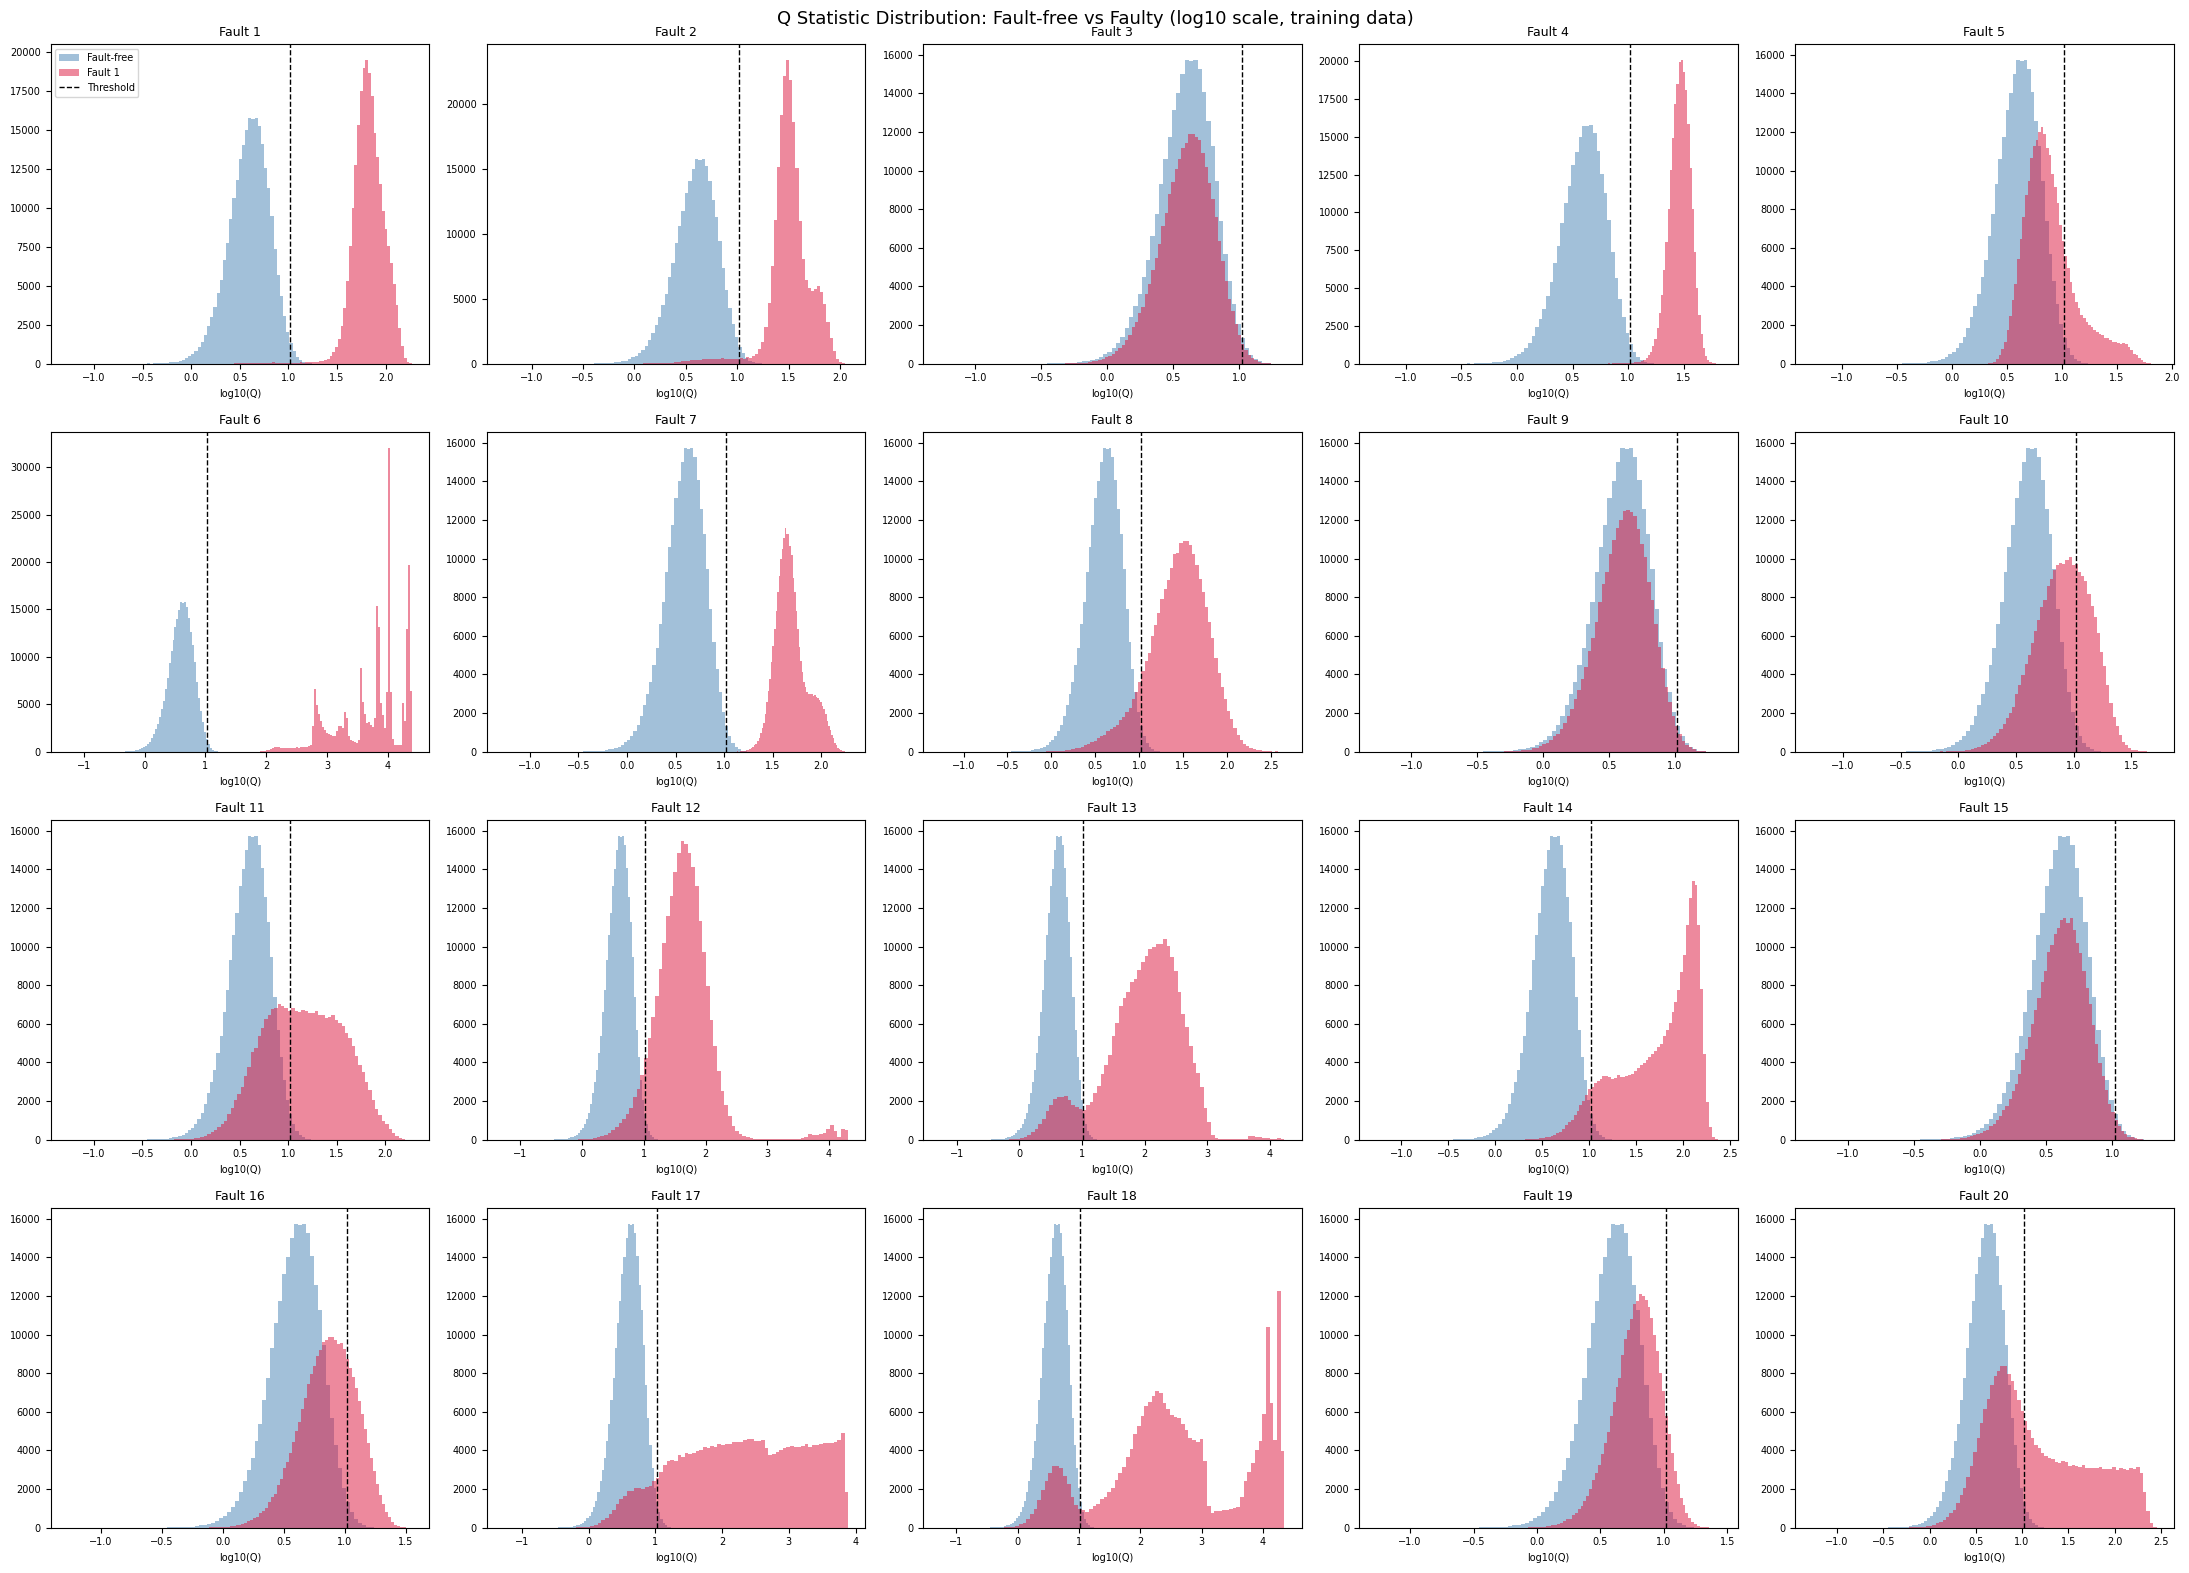

In [37]:
fault_numbers = [f for f in sorted(train_df["faultNumber"].unique()) if f != 0]

fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

for idx, fn in enumerate(fault_numbers):
    ax = axes[idx]
    faulty = train_df[train_df["faultNumber"] == fn][feature_cols].values
    _, Q_faulty = compute_stats(faulty, P, L)
    ax.hist(np.log10(Q_ff + 1e-6),     bins=80, alpha=0.5, color="steelblue", label="Fault-free")
    ax.hist(np.log10(Q_faulty + 1e-6), bins=80, alpha=0.5, color="crimson",   label=f"Fault {fn}")
    ax.axvline(np.log10(Q_thresh_stat), color="black", linestyle="--", linewidth=1, label="Threshold")
    ax.set_title(f"Fault {fn}", fontsize=9)
    ax.set_xlabel("log10(Q)", fontsize=7)
    ax.tick_params(labelsize=7)
    if idx == 0:
        ax.legend(fontsize=7)

for j in range(len(fault_numbers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Q Statistic Distribution: Fault-free vs Faulty (log10 scale, training data)", fontsize=13)
plt.tight_layout()
plt.show()

### Findings

Each plot shows log10(Q) for fault-free (blue) vs faulty (red), with the empirical 99th-percentile threshold as a dashed line.

- **Strong separation:** Faults 1, 2, 4, 6, 7, 14, 17 -- faulty distribution clearly beyond threshold.
- **Moderate separation:** Faults 5, 8, 11, 12, 13, 18, 20 -- shifted right but overlap near threshold; 11 and 20 appear bimodal.
- **Weak/overlapping:** Faults 3, 9, 10, 15, 16, 19 -- heavy overlap with fault-free, Q alone insufficient. Faults 3, 9, 15 are known to be undetectable by linear methods.


## Section 4 - Evaluation & Analysis

### 4.1 - Fault Detection (by Sample and Run)

Evaluate PCA fault detection on the held-out **test set** across all **20 fault classes**.

**Important:** This is binary anomaly detection (normal vs. fault), not multiclass classification. Each fault class is evaluated independently -- for a given fault, we check whether the model flags those samples as anomalous compared to normal operation. The model has no knowledge of fault identity.

**Detection rules (per sample, and per run):**
1. For each sample, check: does **Q > Q_threshold** OR **T2 > T2_threshold**? If yes, the sample *exceeds* the threshold and is classified as faulty
2. Apply the **consecutive-sample rule**: a run triggers an **alarm** when **N_CONSEC = 6 consecutive samples** all exceed the threshold. Isolated threshold crossings are discarded as noise (Russell et al., 2000). This imposes a **minimum detection delay of 15 minutes** (5 additional samples x 3 min/sample after the first exceedance).

**Sample-level metrics** (computed on sample threshold crossings, no consecutive rule):
- **FDR** (Fault Detection Rate) = fraction of post-onset fault samples that exceed the threshold
- **F1** = harmonic mean of precision and recall (fault-free test data used as negatives)
- **Accuracy** = overall correct classifications
- **Global False Positive Rate FPR (sample)** = fraction of fault-free test samples that exceed the threshold

**Run-level metrics** (computed using the consecutive rule):
- **% Runs Detected** = fraction of test runs where at least one alarm (6 consecutive exceedances) occurred after onset
- **Global FPR (consecutive)** = fraction of fault-free test samples that are part of a 6-consecutive alarm (practical false alarm rate)
- **Detection Delay** = time from fault onset to first 6-consecutive alarm, in minutes (samples x 3 min/sample)

In [38]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

TEST_ONSET = 160
N_CONSEC   = 6    # consecutive exceedances required for alarm (Russell et al., 2000)

def apply_consec_rule(flags, n_consec):
    """Apply consecutive-sample rule: only keep flags that are part of a streak >= n_consec."""
    if n_consec <= 1:
        return flags.copy()
    result = np.zeros_like(flags, dtype=bool)
    count = 0
    for i in range(len(flags)):
        if flags[i]:
            count += 1
            if count >= n_consec:
                result[i - n_consec + 1 : i + 1] = True
        else:
            count = 0
    return result

# --- Fault-free test data ---
ff_test = test_df[test_df['faultNumber'] == 0][feature_cols].values
T2_ff_test, Q_ff_test = compute_stats(ff_test, P, L)
ff_raw_flagged = (Q_ff_test > Q_thresh_stat) | (T2_ff_test > T2_thresh_stat)
ff_consec_flagged = apply_consec_rule(ff_raw_flagged, N_CONSEC)

# FPR uses consecutive rule (practical false alarm rate)
global_fpr_raw    = ff_raw_flagged.mean()
global_fpr_consec = ff_consec_flagged.mean()

tn0 = int((~ff_raw_flagged).sum())
fp0 = int(ff_raw_flagged.sum())
results = [{
    'Fault': 0,
    'FDR (Recall)': float('nan'),
    'F1':           float('nan'),
    'Accuracy':     tn0 / (tn0 + fp0),
    '% Runs Detected': float('nan'),
}]

cms = {}
total_tp, total_post_onset = 0, 0

for fn in sorted(test_df['faultNumber'].unique()):
    if fn == 0:
        continue
    fault_data = test_df[test_df['faultNumber'] == fn].copy()
    post_onset = (fault_data['sample'] > TEST_ONSET).values

    X_fault    = fault_data[feature_cols].values
    T2_f, Q_f  = compute_stats(X_fault, P, L)
    raw_flagged = (Q_f > Q_thresh_stat) | (T2_f > T2_thresh_stat)

    # --- Sample-level metrics: use raw threshold crossings ---
    fdr = raw_flagged[post_onset].mean()

    y_true = np.concatenate([np.zeros(len(ff_raw_flagged)), np.ones(post_onset.sum())])
    y_pred = np.concatenate([ff_raw_flagged.astype(int), raw_flagged[post_onset].astype(int)])

    f1  = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cms[fn] = cm

    # --- Run-level metric: % Runs Detected uses consecutive rule ---
    run_ids = fault_data['simulationRun'].unique()
    detected_runs = 0
    for run_id in run_ids:
        mask = (fault_data['simulationRun'] == run_id).values
        run_consec = apply_consec_rule(raw_flagged[mask], N_CONSEC)
        run_samples = fault_data.loc[fault_data['simulationRun'] == run_id, 'sample'].values
        run_post = run_samples > TEST_ONSET
        if run_consec[run_post].any():
            detected_runs += 1

    pct_detected = detected_runs / len(run_ids) * 100

    results.append({
        'Fault': fn,
        'FDR (Recall)': fdr,
        'F1':           f1,
        'Accuracy':     acc,
        '% Runs Detected': pct_detected,
    })
    total_tp         += int(raw_flagged[post_onset].sum())
    total_post_onset += int(post_onset.sum())

results_df = pd.DataFrame(results).set_index('Fault')
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'N_CONSEC = {N_CONSEC} (consecutive exceedances required for alarm)')
print()
print(results_df.to_string())
print()

fault_rows  = results_df.loc[1:]
mean_fdr    = fault_rows['FDR (Recall)'].mean()
mean_f1     = fault_rows['F1'].mean()
mean_acc    = fault_rows['Accuracy'].mean()
# Overall % runs detected: total detected runs / total runs across all faults
total_runs = 0
total_detected_runs = 0
for fn in fault_rows.index:
    fn_data = test_df[test_df['faultNumber'] == fn]
    n_runs = fn_data['simulationRun'].nunique()
    pct = fault_rows.loc[fn, '% Runs Detected']
    total_runs += n_runs
    total_detected_runs += int(round(pct / 100 * n_runs))
overall_pct_detected = total_detected_runs / total_runs * 100
overall_fdr = total_tp / total_post_onset

print('=== Sample-level metrics (raw threshold crossings) ===')
print(f'Mean FDR:          {mean_fdr:.4f} ({mean_fdr*100:.2f}%)')
print(f'Mean F1:           {mean_f1:.4f}')
print(f'Mean Accuracy:     {mean_acc:.4f}')
print(f'Global FPR:        {global_fpr_raw:.4f} ({global_fpr_raw*100:.2f}%)')
print(f'Overall FDR:       {overall_fdr:.4f} ({overall_fdr*100:.2f}%)')
print(f'  Total post-onset samples: {total_post_onset:,}')
print(f'  Total detected:           {total_tp:,}')
print(f'  Total missed:             {total_post_onset - total_tp:,}')
print()
print(f'=== Run-level metrics (consecutive rule, N_CONSEC={N_CONSEC}) ===')
print(f'Overall % Runs Detected: {overall_pct_detected:.2f}% ({total_detected_runs}/{total_runs} runs)')
print(f'Global FPR:           {global_fpr_consec:.6f} ({global_fpr_consec*100:.4f}%)')


N_CONSEC = 6 (consecutive exceedances required for alarm)

       FDR (Recall)     F1  Accuracy  % Runs Detected
Fault                                                
0               NaN    NaN    0.9794              NaN
1            0.9976 0.9866    0.9877         100.0000
2            0.9874 0.9814    0.9830         100.0000
3            0.0226 0.0432    0.5445           1.0000
4            0.9998 0.9877    0.9887         100.0000
5            0.2776 0.4263    0.6604         100.0000
6            1.0000 0.9878    0.9888         100.0000
7            1.0000 0.9878    0.9888         100.0000
8            0.9749 0.9751    0.9773         100.0000
9            0.0232 0.0444    0.5448           1.0000
10           0.4641 0.6235    0.7452         100.0000
11           0.7865 0.8684    0.8917         100.0000
12           0.9870 0.9813    0.9829         100.0000
13           0.9491 0.9617    0.9656         100.0000
14           0.9996 0.9876    0.9886         100.0000
15           0.0254 0.0

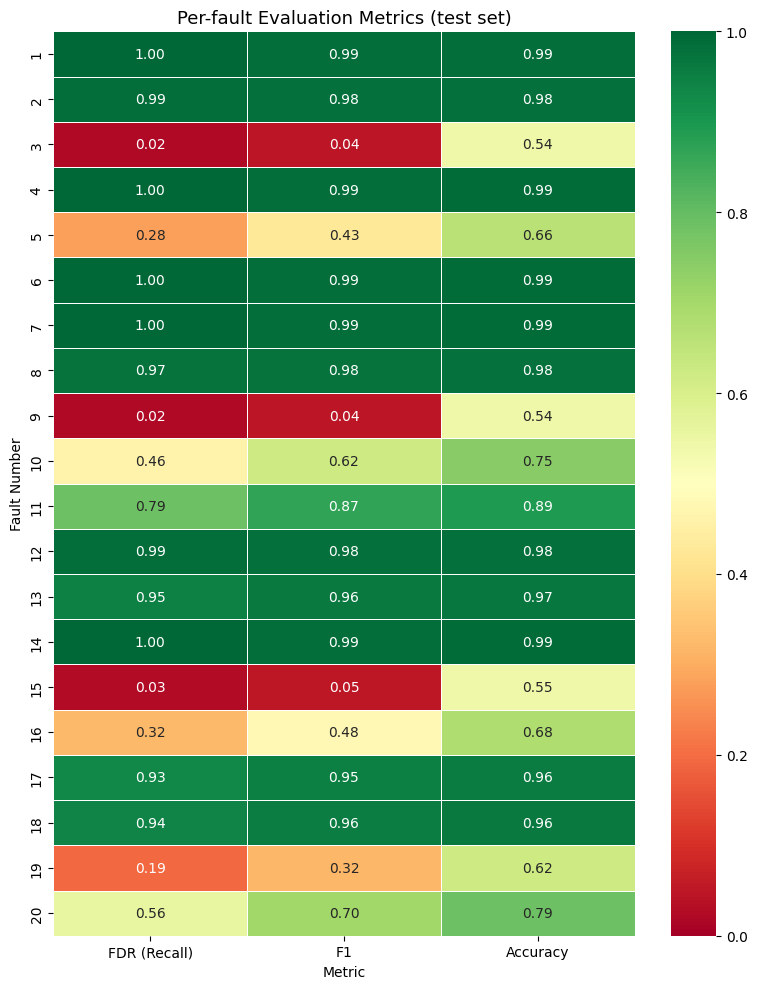

In [39]:
# Heatmap: FDR, F1, Accuracy per fault
metrics_to_plot = ["FDR (Recall)", "F1", "Accuracy"]
plot_data = results_df.loc[1:][metrics_to_plot]

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    plot_data,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title("Per-fault Evaluation Metrics (test set)", fontsize=13)
ax.set_xlabel("Metric")
ax.set_ylabel("Fault Number")
plt.tight_layout()
plt.show()

In [40]:
for fn, cm in sorted(cms.items()):
    print(f"The Confusion Matrix for Fault {fn}:")
    print(cm)
    print()

The Confusion Matrix for Fault 1:
[[470109   9891]
 [   966 399034]]

The Confusion Matrix for Fault 2:
[[470109   9891]
 [  5044 394956]]

The Confusion Matrix for Fault 3:
[[470109   9891]
 [390960   9040]]

The Confusion Matrix for Fault 4:
[[470109   9891]
 [    91 399909]]

The Confusion Matrix for Fault 5:
[[470109   9891]
 [288949 111051]]

The Confusion Matrix for Fault 6:
[[470109   9891]
 [     0 400000]]

The Confusion Matrix for Fault 7:
[[470109   9891]
 [     0 400000]]

The Confusion Matrix for Fault 8:
[[470109   9891]
 [ 10051 389949]]

The Confusion Matrix for Fault 9:
[[470109   9891]
 [390702   9298]]

The Confusion Matrix for Fault 10:
[[470109   9891]
 [214354 185646]]

The Confusion Matrix for Fault 11:
[[470109   9891]
 [ 85417 314583]]

The Confusion Matrix for Fault 12:
[[470109   9891]
 [  5193 394807]]

The Confusion Matrix for Fault 13:
[[470109   9891]
 [ 20363 379637]]

The Confusion Matrix for Fault 14:
[[470109   9891]
 [   167 399833]]

The Confusion M

### Findings

**Per-fault metrics (FDR = sample-level, % Runs Detected = run-level with N_CONSEC=6):**

| Fault | FDR (Recall) | F1 | Accuracy | % Runs Detected |
|-------|-------------|------|----------|------------------|
| 0 (fault-free) | -- | -- | 97.94% | -- |
| 1 | 99.76% | 0.9866 | 98.77% | 100% |
| 2 | 98.74% | 0.9814 | 98.30% | 100% |
| 3 | 2.26% | 0.0432 | 54.45% | 1.0% |
| 4 | 99.98% | 0.9877 | 98.87% | 100% |
| 5 | 27.76% | 0.4263 | 66.04% | 100% |
| 6 | 100.00% | 0.9878 | 98.88% | 100% |
| 7 | 100.00% | 0.9878 | 98.88% | 100% |
| 8 | 97.49% | 0.9751 | 97.73% | 100% |
| 9 | 2.32% | 0.0444 | 54.48% | 1.0% |
| 10 | 46.41% | 0.6235 | 74.52% | 100% |
| 11 | 78.65% | 0.8684 | 89.17% | 100% |
| 12 | 98.70% | 0.9813 | 98.29% | 100% |
| 13 | 94.91% | 0.9617 | 96.56% | 100% |
| 14 | 99.96% | 0.9876 | 98.86% | 100% |
| 15 | 2.54% | 0.0484 | 54.58% | 0.8% |
| 16 | 32.08% | 0.4769 | 68.00% | 100% |
| 17 | 93.04% | 0.9518 | 95.71% | 100% |
| 18 | 93.90% | 0.9564 | 96.10% | 100% |
| 19 | 19.26% | 0.3164 | 62.18% | 43.2% |
| 20 | 55.76% | 0.7048 | 78.77% | 100% |

**Sample-level summary:**
- **Mean FDR:** 67.18% | **Mean F1:** 0.7149 | **Mean Accuracy:** 83.96%
- **Global FPR:** 2.06%

**Run-level summary (N_CONSEC = 6):**
- **Overall runs detected:** 82.30% (8,230 / 10,000 runs)
- **Global FPR (consecutive):** 0.0063%

**By fault difficulty:**
- *Strong (FDR > 90%):* Faults 1, 2, 4, 6, 7, 8, 12, 13, 14, 17, 18 -- faults 6 and 7 achieve perfect sample-level detection.
- *Moderate (FDR 40-80%):* Faults 10, 11, 20 -- all runs detected, but significant faulty samples fall below threshold.
- *Weak (FDR < 30%):* Faults 5, 16, 19 -- fault 19 worst with only 43.2% runs detected.
- *Near-zero (FDR < 3%):* Faults 3, 9, 15 -- undetectable by linear PCA.

**Note:** FP is global (not per-fault) since this is binary classification. Global FPR = 2.06% at sample level, dropping to 0.0063% with the consecutive rule.

**Key takeaway:** PCA detects 82.30% of fault runs with near-zero false alarm rate. Effective for 14/20 faults, with a clear ceiling on faults 3, 5, 9, 15, 16, 19.


### 4.2 - Detection Timing

How quickly does the model detect each fault after onset?

For each test run, the **detection delay** is the number of samples between fault onset (sample 160) and the first sample that is part of a **N_CONSEC consecutive alarm streak** (Q > Q_threshold OR T2 > T2_threshold for N_CONSEC samples in a row). Multiplied by 3 min/sample (TEP sampling interval) to convert to minutes.

- A delay of 0 means the alarm triggered at the very first post-onset samples
- Runs where no post-onset streak of N_CONSEC consecutive flags occurs are counted as missed and excluded from delay statistics
- **MDR** (Missed Detection Rate) = fraction of faulty runs that did **not** trigger a consecutive alarm (run-level metric, not sample-level)
- **% Runs Detected** = fraction of runs where at least one N_CONSEC-length alarm was raised after onset

In [41]:
TEST_ONSET   = 160
SAMPLE_MINS  = 3   # TEP sampling interval: 3 minutes per sample

timing_rows = []

for fn in sorted(test_df['faultNumber'].unique()):
    if fn == 0:
        continue

    fault_data = test_df[test_df['faultNumber'] == fn].copy()
    X_fault    = fault_data[feature_cols].values
    T2_f, Q_f  = compute_stats(X_fault, P, L)
    raw_flagged = (Q_f > Q_thresh_stat) | (T2_f > T2_thresh_stat)

    # MDR: fraction of faulty runs that did NOT trigger a consecutive alarm
    # Note: pre-onset samples already removed in preprocessing
    delays = []
    run_ids = fault_data['simulationRun'].unique()
    detected_runs = 0

    for run_id in run_ids:
        mask      = (fault_data['simulationRun'] == run_id).values
        samples   = fault_data.loc[fault_data['simulationRun'] == run_id, 'sample'].values
        run_flags = apply_consec_rule(raw_flagged[mask], N_CONSEC)

        first_flagged = np.where(run_flags)[0]
        if len(first_flagged) > 0:
            # Alarm is raised at the end of the first N_CONSEC streak
            alarm_idx = first_flagged[0] + (N_CONSEC - 1)
            delay_samples = samples[alarm_idx] - TEST_ONSET
            delays.append(delay_samples * SAMPLE_MINS)
            detected_runs += 1

    pct_detected = detected_runs / len(run_ids) * 100
    mdr = 1.0 - (detected_runs / len(run_ids))

    timing_rows.append({
        'Fault': int(fn),
        'MDR': round(mdr, 4),
        'Mean Delay (min)': round(float(np.mean(delays)), 1) if delays else float('nan'),
        'Median Delay (min)': round(float(np.median(delays)), 1) if delays else float('nan'),
        '% Runs Detected': round(pct_detected, 1),
    })

timing_df = pd.DataFrame(timing_rows).set_index('Fault')
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'N_CONSEC = {N_CONSEC} | Sampling interval: {SAMPLE_MINS} min/sample | Onset: sample {TEST_ONSET}')
print()
print(timing_df.to_string())
print()
all_delays = [d for row in timing_rows for d in ([row["Mean Delay (min)"]] if not np.isnan(row["Mean Delay (min)"]) else [])]
print(f'Mean detection delay (detected runs only): {np.mean(all_delays):.1f} min')
print(f'Median detection delay (across fault medians): {np.median(timing_df["Median Delay (min)"].dropna()):.1f} min')

N_CONSEC = 6 | Sampling interval: 3 min/sample | Onset: sample 160

         MDR  Mean Delay (min)  Median Delay (min)  % Runs Detected
Fault                                                              
1     0.0000           24.0000             24.0000         100.0000
2     0.0000           50.6000             51.0000         100.0000
3     0.9900         1354.2000           1368.0000           1.0000
4     0.0000           19.0000             18.0000         100.0000
5     0.0000           18.7000             18.0000         100.0000
6     0.0000           18.0000             18.0000         100.0000
7     0.0000           18.0000             18.0000         100.0000
8     0.0000           77.9000             72.0000         100.0000
9     0.9900         1585.8000           1641.0000           1.0000
10    0.0000          245.5000            201.0000         100.0000
11    0.0000           45.6000             39.0000         100.0000
12    0.0000           43.5000             39.00

### Findings

Detection delay = time from fault onset to the 6th consecutive threshold exceedance (when alarm fires). MDR = fraction of faulty runs that did not trigger a consecutive alarm. Delay computed over detected runs only.

**Why N_CONSEC = 6?** With independent observations and a per-sample false alarm rate of alpha = 0.01, requiring 6 consecutive exceedances reduces the false alarm probability to 0.01^6 = 10-^1^2 per sample (Russell et al., 2000). This makes spurious alarms effectively impossible while adding only a 15-minute detection lag (5 extra samples x 3 min).

- **Mean detection delay:** 353.9 min | **Median (across fault medians):** 90.0 min

**By speed:**
- *Immediate (median <= 24 min):* Faults 1, 4, 5, 6, 7, 14 -- alarm within minutes of onset.
- *Moderate (39-72 min):* Faults 2, 8, 11, 12 -- detected within ~1 hour.
- *Slow (> 100 min):* Faults 10, 13, 16, 17, 18, 20 -- detection takes hours due to weaker or intermittent signal.
- *Essentially undetected:* Faults 3, 9, 15 (MDR > 0.99), Fault 19 (MDR = 0.568, 43.2% runs detected).


### 4.3 - Contribution Heatmap

For each fault, the per-variable contribution to SPE (Q) is computed as:

`contribution[var] = |x[var] * (x[var] - x_reconstructed[var])|`

Averaged over all post-onset samples that were correctly detected (TP samples), this shows which features are most responsible for driving the reconstruction error during each fault. High contribution indicates the variable behaves anomalously relative to the normal PCA subspace.

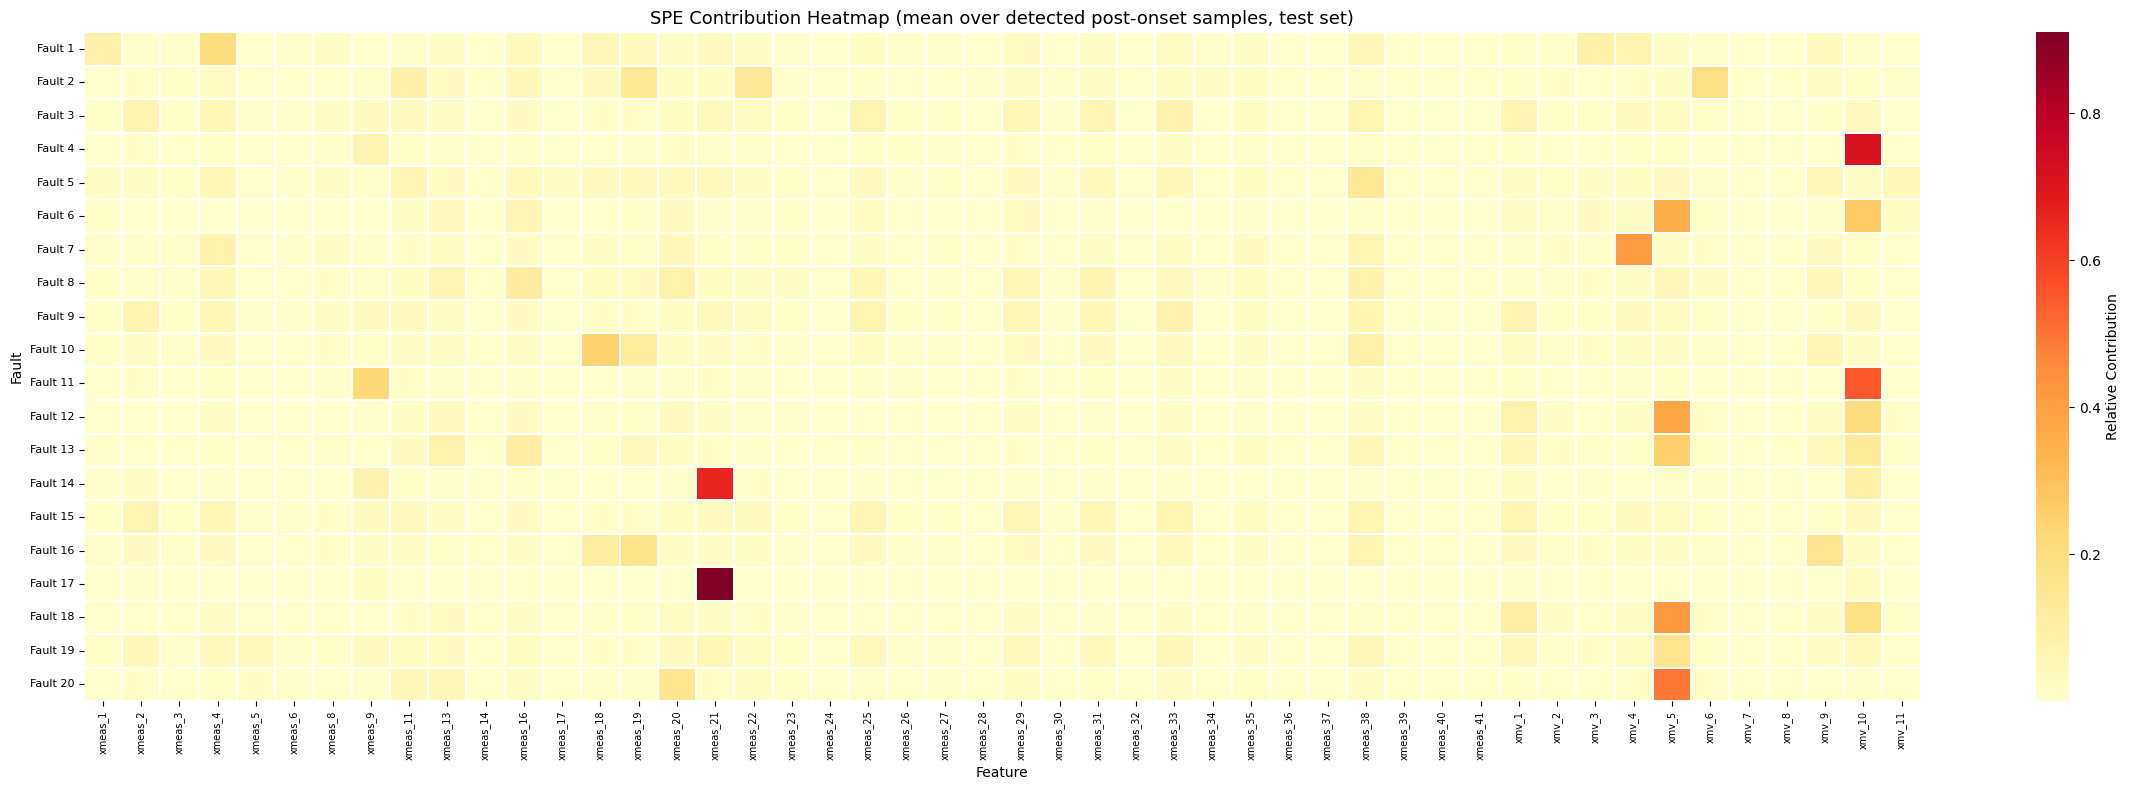

In [42]:
def compute_contributions(X, P):
    """Per-variable SPE contribution: |x * (x - x_reconstructed)|"""
    T      = X @ P
    X_recon = T @ P.T
    return np.abs(X * (X - X_recon))

TEST_ONSET = 160
fault_numbers = [f for f in sorted(test_df["faultNumber"].unique()) if f != 0]

# Compute mean contribution per fault over detected post-onset samples
contrib_matrix = np.zeros((len(fault_numbers), len(feature_cols)))

for i, fn in enumerate(fault_numbers):
    fault_data = test_df[test_df["faultNumber"] == fn].copy()
    post_onset = (fault_data["sample"] > TEST_ONSET).values
    X_fault    = fault_data[feature_cols].values
    T2_f, Q_f  = compute_stats(X_fault, P, L)
    flagged    = (Q_f > Q_thresh_stat) | (T2_f > T2_thresh_stat)
    tp_mask    = post_onset & flagged
    if tp_mask.sum() > 0:
        contribs = compute_contributions(X_fault[tp_mask], P)
        contrib_matrix[i] = contribs.mean(axis=0)

# Normalize each fault row so contributions sum to 1 (relative importance)
contrib_norm = contrib_matrix / (contrib_matrix.sum(axis=1, keepdims=True) + 1e-10)

contrib_df = pd.DataFrame(
    contrib_norm,
    index=[f"Fault {fn}" for fn in fault_numbers],
    columns=feature_cols
)

fig, ax = plt.subplots(figsize=(24, 8))
sns.heatmap(
    contrib_df,
    cmap="YlOrRd", linewidths=0.2,
    ax=ax, cbar_kws={"label": "Relative Contribution"}
)
ax.set_title("SPE Contribution Heatmap (mean over detected post-onset samples, test set)", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("Fault")
ax.tick_params(axis="x", labelsize=7, rotation=90)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

### Findings

The heatmap shows normalized per-variable SPE contribution averaged over detected post-onset test samples. Each row sums to 1.

**Dominant features by fault:**
- **xmeas_21** (Reactor Cooling Water Out) -- dominates Faults 14 and 17
- **xmv_10** (Reactor Cooling Water Valve) -- dominates Faults 4, 6, 11
- **xmv_4** (Total Feed Flow Valve) -- dominates Fault 7
- **xmv_5** (Compressor Recycle Valve) -- medium impact across Faults 6, 12, 13, 18, 19, 20

**Diffuse/weak faults:** Faults 3, 9, 15 -- no clear dominant feature, contributions spread thinly, consistent with near-zero detection in Section 4.1.

**Overall:** Most detectable faults show 1--2 dominant features. Difficult faults lack a concentrated SPE signature.

## Section 5 -- DPCA Model

Static PCA treats each sample independently -- it ignores the fact that consecutive measurements in a chemical process are temporally correlated. **Dynamic PCA (DPCA)** extends PCA by augmenting each observation vector with *l* lagged observations, forming a time-lagged data matrix (Ku et al., 1995; Russell et al., 2000).

For an observation vector $x_t$ of dimension $m$ and lag $l$, the augmented vector is:

$$	ilde{x}_t = [x_t^T, x_{t-1}^T, \ldots, x_{t-l}^T]^T \in \mathbb{R}^{m(l+1)}$$

PCA is then applied to this augmented matrix. With $m = 48$ features and $l = 2$ lags, the augmented vector has $48 	imes 3 = 144$ dimensions. The resulting T2 and Q statistics capture both cross-variable correlations (as in static PCA) **and** temporal autocorrelations.

**Key design choice:** the number of lags *l*. Yin et al. (2012) used $l = 2$ with 42 PCs (90% variance) on TEP. Russell et al. (2000) used $l = 2$-$3$ per fault. We follow the literature convention of $l = 2$.

### 5.1 -- Lag Selection & Model Fitting

1. Select lag $l = 2$ following literature convention (Yin et al., 2012; Russell et al., 2000).
2. Build the time-lagged data matrix for that lag.
3. Fit PCA on the augmented matrix, selecting components at 90% cumulative variance.
4. Compare the number of components to static PCA (expect more, since the augmented matrix has $m(l+1)$ columns).

In [43]:
# --- Lag selection ---
# Literature convention: l=2 for TEP (Yin et al., 2012; Russell et al., 2000)
# AIC on this data decreases through l=5, but higher lags risk overfitting
# autocorrelation noise and inflate the component count.
ff_train = train_df[train_df['faultNumber'] == 0][feature_cols].values
best_lag = 2
print(f'Selected lag: l = {best_lag} (literature convention)')

# --- Build time-lagged matrix ---
def build_lagged_matrix(X, lag):
    """Augment each row with l previous rows. Returns matrix with first l rows dropped."""
    n, m = X.shape
    X_lagged = np.hstack([X[lag - i : n - i] for i in range(lag + 1)])
    return X_lagged

ff_train_lagged = build_lagged_matrix(ff_train, best_lag)
print(f'Original fault-free shape: {ff_train.shape}')
print(f'Lagged fault-free shape:  {ff_train_lagged.shape}  (m*(l+1) = {ff_train.shape[1]}*{best_lag+1} = {ff_train.shape[1]*(best_lag+1)})')

# --- Fit PCA on lagged matrix ---
cov_lagged = np.cov(ff_train_lagged, rowvar=False)
eigenvalues_lagged, eigenvectors_lagged = np.linalg.eigh(cov_lagged)

# Sort descending
idx = np.argsort(eigenvalues_lagged)[::-1]
eigenvalues_lagged = eigenvalues_lagged[idx]
eigenvectors_lagged = eigenvectors_lagged[:, idx]

# Select components at 90% cumulative variance
cumvar = np.cumsum(eigenvalues_lagged) / np.sum(eigenvalues_lagged)
n_components_dpca = np.argmax(cumvar >= 0.90) + 1

P_dpca = eigenvectors_lagged[:, :n_components_dpca]
L_dpca = eigenvalues_lagged[:n_components_dpca]
all_eigenvalues_dpca = eigenvalues_lagged

print(f'DPCA components (90% variance): {n_components_dpca}')
print(f'Static PCA components (90% variance): {N_COMPONENTS}')
print(f'Cumulative variance at {n_components_dpca} components: {cumvar[n_components_dpca-1]:.4f}')

Selected lag: l = 2 (literature convention)
Original fault-free shape: (250000, 48)
Lagged fault-free shape:  (249998, 144)  (m*(l+1) = 48*3 = 144)
DPCA components (90% variance): 70
Static PCA components (90% variance): 32
Cumulative variance at 70 components: 0.9033


### Findings

- **Lag:** l = 2 (literature convention, Yin et al. 2012)
- **Augmented matrix:** 249,998 rows x 144 columns (48 features x 3 time steps)
- **DPCA components (90% variance):** 70 (vs 32 for static PCA)
- More components expected: the lagged matrix has 3x the columns, and temporal correlations introduce additional variance directions that PCA must capture.
- Yin et al. (2012) reported 42 components with l=2 on 33 variables; our 70 on 48 variables is consistent given the larger feature set.

### 5.2 -- Threshold Computation

Same threshold framework as static PCA (Section 3.1), applied to the DPCA model:
- T2 threshold: F-distribution at 99% confidence
- Q threshold: Jackson-Mudholkar method at 99% confidence

Thresholds are computed on fault-free training data projected through the DPCA model. Because lagged samples are temporally correlated, the Jackson-Mudholkar Q threshold can overestimate sensitivity (inflated FPR). We use **empirical 99th percentile** thresholds from the fault-free training data to guarantee 1% FPR, following the approach in Russell et al. (2000) who also adjusted thresholds to match a target significance level.

In [44]:
# Compute DPCA stats on fault-free training data
T2_ff_dpca, Q_ff_dpca = compute_stats(ff_train_lagged, P_dpca, L_dpca)

n_dpca = len(ff_train_lagged)
a_dpca = n_components_dpca

T2_thresh_dpca_stat = t2_threshold(n_dpca, a_dpca, conf=0.99)
Q_thresh_dpca_stat  = q_threshold(all_eigenvalues_dpca, a_dpca, conf=0.99)

# FPR sanity check on analytical thresholds
fpr_t2_stat = (T2_ff_dpca > T2_thresh_dpca_stat).mean()
fpr_q_stat  = (Q_ff_dpca > Q_thresh_dpca_stat).mean()

print('Analytical thresholds (99% confidence):')
print(f'  T2 (F-distribution):      {T2_thresh_dpca_stat:.4f}  (FPR: {fpr_t2_stat:.4f})')
print(f'  Q  (Jackson-Mudholkar):   {Q_thresh_dpca_stat:.4f}  (FPR: {fpr_q_stat:.4f})')
print()

# JM Q threshold gives ~5.5% FPR -- lagged samples violate the independence
# assumption. Use empirical 99th percentile instead for fair comparison.
T2_thresh_dpca = np.percentile(T2_ff_dpca, 99)
Q_thresh_dpca  = np.percentile(Q_ff_dpca, 99)

fpr_t2_emp = (T2_ff_dpca > T2_thresh_dpca).mean()
fpr_q_emp  = (Q_ff_dpca > Q_thresh_dpca).mean()

print('Empirical thresholds (99th percentile of fault-free data):')
print(f'  T2: {T2_thresh_dpca:.4f}  (FPR: {fpr_t2_emp:.4f})')
print(f'  Q:  {Q_thresh_dpca:.4f}  (FPR: {fpr_q_emp:.4f})')
print()
print('Static PCA thresholds for comparison:')
print(f'  T2: {T2_thresh_stat:.4f}')
print(f'  Q:  {Q_thresh_stat:.4f}')

Analytical thresholds (99% confidence):
  T2 (F-distribution):      100.4598  (FPR: 0.0127)
  Q  (Jackson-Mudholkar):   22.7077  (FPR: 0.0555)

Empirical thresholds (99th percentile of fault-free data):
  T2: 101.9010  (FPR: 0.0100)
  Q:  28.5974  (FPR: 0.0100)

Static PCA thresholds for comparison:
  T2: 53.4467
  Q:  10.4572


### Findings

**Analytical thresholds** (JM/F-distribution) gave inflated FPR for DPCA -- T2 at 1.27% and Q at 5.55% -- because lagged samples violate the independence assumption. **Empirical 99th percentile thresholds** used instead:

| Statistic | DPCA Threshold | Static PCA Threshold |
|-----------|---------------|---------------------|
| T2 | 101.90 | 53.45 |
| Q | 28.60 | 10.46 |

Both empirical thresholds give exactly 1% FPR on fault-free training data. DPCA thresholds are roughly 2x higher than static PCA, reflecting the larger model (70 components, 144-dim input) -- normal variation is spread across more dimensions, so the baseline T2 and Q values are higher.

## Section 6 -- DPCA Evaluation & Analysis

### 6.1 -- Fault Detection (by Sample and Run)

Same evaluation framework as static PCA (Section 4.1). Binary anomaly detection using DPCA T2/Q statistics with empirical thresholds and N_CONSEC = 6 consecutive-sample rule. Sample-level metrics use raw threshold crossings; run-level metrics use the consecutive rule.

**Note:** Each test run must be converted to a lagged matrix before computing DPCA statistics. The first *l* samples of each run are lost to lagging.

In [45]:
# --- Fault-free test data (DPCA) ---
ff_test_raw = test_df[test_df['faultNumber'] == 0][feature_cols].values
ff_test_lagged = build_lagged_matrix(ff_test_raw, best_lag)

T2_ff_test_dpca, Q_ff_test_dpca = compute_stats(ff_test_lagged, P_dpca, L_dpca)
ff_raw_flagged_dpca = (Q_ff_test_dpca > Q_thresh_dpca) | (T2_ff_test_dpca > T2_thresh_dpca)
ff_consec_flagged_dpca = apply_consec_rule(ff_raw_flagged_dpca, N_CONSEC)

global_fpr_raw_dpca    = ff_raw_flagged_dpca.mean()
global_fpr_consec_dpca = ff_consec_flagged_dpca.mean()

tn0_dpca = int((~ff_raw_flagged_dpca).sum())
fp0_dpca = int(ff_raw_flagged_dpca.sum())

results_dpca = [{
    'Fault': 0,
    'FDR (Recall)': float('nan'),
    'F1':           float('nan'),
    'Accuracy':     tn0_dpca / (tn0_dpca + fp0_dpca),
    '% Runs Detected': float('nan'),
}]

total_tp_dpca, total_post_onset_dpca = 0, 0

for fn in sorted(test_df['faultNumber'].unique()):
    if fn == 0:
        continue

    fault_data = test_df[test_df['faultNumber'] == fn].copy()

    # Build lagged matrix per run to avoid cross-run contamination
    all_raw_flagged = []
    all_samples = []
    run_ids = fault_data['simulationRun'].unique()
    detected_runs = 0

    for run_id in run_ids:
        run_data = fault_data[fault_data['simulationRun'] == run_id].sort_values('sample')
        X_run = run_data[feature_cols].values
        samples_run = run_data['sample'].values

        if len(X_run) <= best_lag:
            continue

        X_run_lagged = build_lagged_matrix(X_run, best_lag)
        samples_lagged = samples_run[best_lag:]  # first l samples lost to lagging

        T2_run, Q_run = compute_stats(X_run_lagged, P_dpca, L_dpca)
        run_flagged = (Q_run > Q_thresh_dpca) | (T2_run > T2_thresh_dpca)

        all_raw_flagged.append(run_flagged)
        all_samples.append(samples_lagged)

        # Run-level: consecutive rule
        run_consec = apply_consec_rule(run_flagged, N_CONSEC)
        if run_consec.any():
            detected_runs += 1

    all_raw_flagged = np.concatenate(all_raw_flagged)
    all_samples = np.concatenate(all_samples)

    # Sample-level metrics
    fdr = all_raw_flagged.mean()

    y_true = np.concatenate([np.zeros(len(ff_raw_flagged_dpca)), np.ones(len(all_raw_flagged))])
    y_pred = np.concatenate([ff_raw_flagged_dpca.astype(int), all_raw_flagged.astype(int)])

    f1  = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)

    pct_detected = detected_runs / len(run_ids) * 100

    results_dpca.append({
        'Fault': fn,
        'FDR (Recall)': fdr,
        'F1':           f1,
        'Accuracy':     acc,
        '% Runs Detected': pct_detected,
    })
    total_tp_dpca         += int(all_raw_flagged.sum())
    total_post_onset_dpca += len(all_raw_flagged)

results_dpca_df = pd.DataFrame(results_dpca).set_index('Fault')

print(f'N_CONSEC = {N_CONSEC}')
print()
print(results_dpca_df.to_string())
print()

fault_rows_dpca = results_dpca_df.loc[1:]
mean_fdr_dpca    = fault_rows_dpca['FDR (Recall)'].mean()
mean_f1_dpca     = fault_rows_dpca['F1'].mean()
mean_acc_dpca    = fault_rows_dpca['Accuracy'].mean()

total_runs_dpca = 0
total_detected_dpca = 0
for fn in fault_rows_dpca.index:
    fn_data = test_df[test_df['faultNumber'] == fn]
    n_runs = fn_data['simulationRun'].nunique()
    pct = fault_rows_dpca.loc[fn, '% Runs Detected']
    total_runs_dpca += n_runs
    total_detected_dpca += int(round(pct / 100 * n_runs))
overall_pct_detected_dpca = total_detected_dpca / total_runs_dpca * 100
overall_fdr_dpca = total_tp_dpca / total_post_onset_dpca

print('=== Sample-level metrics (raw threshold crossings) ===')
print(f'Mean FDR:          {mean_fdr_dpca:.4f} ({mean_fdr_dpca*100:.2f}%)')
print(f'Mean F1:           {mean_f1_dpca:.4f}')
print(f'Mean Accuracy:     {mean_acc_dpca:.4f}')
print(f'Global FPR:        {global_fpr_raw_dpca:.4f} ({global_fpr_raw_dpca*100:.2f}%)')
print(f'Overall FDR:       {overall_fdr_dpca:.4f} ({overall_fdr_dpca*100:.2f}%)')
print()
print(f'=== Run-level metrics (consecutive rule, N_CONSEC={N_CONSEC}) ===')
print(f'Overall % Runs Detected: {overall_pct_detected_dpca:.2f}% ({total_detected_dpca}/{total_runs_dpca} runs)')
print(f'Global FPR (consecutive): {global_fpr_consec_dpca:.6f} ({global_fpr_consec_dpca*100:.4f}%)')

N_CONSEC = 6

       FDR (Recall)     F1  Accuracy  % Runs Detected
Fault                                                
0               NaN    NaN    0.9799              NaN
1            0.9991 0.9876    0.9886         100.0000
2            0.9889 0.9824    0.9840         100.0000
3            0.0209 0.0399    0.5446           4.2000
4            1.0000 0.9881    0.9890         100.0000
5            0.2780 0.4270    0.6613         100.0000
6            1.0000 0.9881    0.9890         100.0000
7            1.0000 0.9881    0.9890         100.0000
8            0.9759 0.9758    0.9781         100.0000
9            0.0215 0.0411    0.5448           4.0000
10           0.4128 0.5745    0.7225         100.0000
11           0.9282 0.9508    0.9564         100.0000
12           0.9901 0.9831    0.9845         100.0000
13           0.9498 0.9623    0.9662         100.0000
14           1.0000 0.9880    0.9890         100.0000
15           0.0235 0.0449    0.5458           6.2000
16           0

### Findings

**Overall comparison (PCA vs DPCA):**

| Metric | PCA | DPCA | Delta |
|--------|-----|------|-------|
| Mean FDR | 67.18% | 68.63% | +1.45% |
| Mean F1 | 0.7149 | 0.7274 | +0.013 |
| Mean Accuracy | 83.96% | 84.66% | +0.70% |
| Overall Runs Detected | 82.30% | 85.72% | +3.42% |
| Global FPR (raw) | 2.06% | 2.01% | -0.05% |
| Global FPR (consecutive) | 0.0063% | 0.0329% | +0.027% |

**Per-fault highlights (FDR):**

| Fault | PCA | DPCA | Change | Note |
|-------|-----|------|--------|------|
| 11 | 78.65% | 92.82% | +14.2% | Biggest gain -- temporal dynamics help |
| 19 | 19.26% | 34.36% | +15.1% | Nearly doubled, still weak |
| 17 | 93.04% | 94.93% | +1.9% | Slight improvement |
| 10 | 46.41% | 41.28% | -5.1% | Slightly worse |
| 3 | 2.26% | 2.09% | ~same | Still undetectable |
| 9 | 2.32% | 2.15% | ~same | Still undetectable |
| 15 | 2.54% | 2.35% | ~same | Still undetectable |

**Run-level: faults 3, 9, 15** improved slightly (PCA: ~1% -> DPCA: 4-6% runs detected) but remain essentially undetectable.

**Takeaway:** DPCA gives modest overall improvement (+3.4% runs detected), with the biggest gains on Fault 11 and Fault 19 -- both faults where temporal autocorrelation carries discriminative signal. Faults 3, 9, 15 remain a hard ceiling for linear methods. Consistent with Russell et al. (2000): DPCA gives "similar performance as PCA for most faults."


### 6.2 -- Detection Timing

Same framework as PCA (Section 4.2). Detection delay = time from fault onset to the 6th consecutive threshold exceedance. MDR = fraction of faulty runs that did not trigger a consecutive alarm.

In [46]:
TEST_ONSET   = 160
SAMPLE_MINS  = 3

timing_rows_dpca = []

for fn in sorted(test_df['faultNumber'].unique()):
    if fn == 0:
        continue

    fault_data = test_df[test_df['faultNumber'] == fn].copy()
    delays = []
    run_ids = fault_data['simulationRun'].unique()
    detected_runs = 0

    for run_id in run_ids:
        run_data = fault_data[fault_data['simulationRun'] == run_id].sort_values('sample')
        X_run = run_data[feature_cols].values
        samples_run = run_data['sample'].values

        if len(X_run) <= best_lag:
            continue

        X_run_lagged = build_lagged_matrix(X_run, best_lag)
        samples_lagged = samples_run[best_lag:]

        T2_run, Q_run = compute_stats(X_run_lagged, P_dpca, L_dpca)
        run_flagged = (Q_run > Q_thresh_dpca) | (T2_run > T2_thresh_dpca)
        run_consec = apply_consec_rule(run_flagged, N_CONSEC)

        first_flagged = np.where(run_consec)[0]
        if len(first_flagged) > 0:
            # Alarm fires at the end of the first N_CONSEC streak
            alarm_idx = first_flagged[0] + (N_CONSEC - 1)
            delay_samples = samples_lagged[alarm_idx] - TEST_ONSET
            delays.append(delay_samples * SAMPLE_MINS)
            detected_runs += 1

    pct_detected = detected_runs / len(run_ids) * 100
    mdr = 1.0 - (detected_runs / len(run_ids))

    timing_rows_dpca.append({
        'Fault': int(fn),
        'MDR': round(mdr, 4),
        'Mean Delay (min)': round(float(np.mean(delays)), 1) if delays else float('nan'),
        'Median Delay (min)': round(float(np.median(delays)), 1) if delays else float('nan'),
        '% Runs Detected': round(pct_detected, 1),
    })

timing_dpca_df = pd.DataFrame(timing_rows_dpca).set_index('Fault')

print(f'N_CONSEC = {N_CONSEC} | Sampling interval: {SAMPLE_MINS} min/sample | Onset: sample {TEST_ONSET}')
print()
print(timing_dpca_df.to_string())
print()
all_delays_dpca = [d for row in timing_rows_dpca for d in ([row['Mean Delay (min)']] if not np.isnan(row['Mean Delay (min)']) else [])]
print(f'Mean detection delay (detected runs only): {np.mean(all_delays_dpca):.1f} min')
print(f'Median detection delay (across fault medians): {np.median(timing_dpca_df["Median Delay (min)"].dropna()):.1f} min')

N_CONSEC = 6 | Sampling interval: 3 min/sample | Onset: sample 160

         MDR  Mean Delay (min)  Median Delay (min)  % Runs Detected
Fault                                                              
1     0.0000           26.2000             27.0000         100.0000
2     0.0000           51.9000             51.0000         100.0000
3     0.9580         1022.3000           1038.0000           4.2000
4     0.0000           24.0000             24.0000         100.0000
5     0.0000           24.0000             24.0000         100.0000
6     0.0000           24.0000             24.0000         100.0000
7     0.0000           24.0000             24.0000         100.0000
8     0.0000           80.5000             75.0000         100.0000
9     0.9600         1004.1000           1084.5000           4.0000
10    0.0000          229.0000            183.0000         100.0000
11    0.0000           37.5000             33.0000         100.0000
12    0.0000           42.3000             39.00

### Findings

**Detection timing comparison (PCA vs DPCA):**

| Metric | PCA | DPCA | Delta |
|--------|-----|------|-------|
| Mean delay | 353.9 min | 230.0 min | -123.9 min |
| Median delay (across faults) | 90.0 min | 91.5 min | +1.5 min |

**Per-fault highlights:**

| Fault | PCA Median (min) | DPCA Median (min) | PCA % Runs | DPCA % Runs | Note |
|-------|-----------------|-------------------|------------|-------------|------|
| 19 | 1038.0 | 184.5 | 43.2% | **100%** | Dramatic improvement -- previously worst fault |
| 11 | 39.0 | 33.0 | 100% | 100% | Faster detection |
| 16 | 165.0 | 135.0 | 100% | 100% | -30 min |
| 10 | 201.0 | 183.0 | 100% | 100% | -18 min |
| 3 | 1368.0 | 1038.0 | 1.0% | 4.2% | Still near-zero |
| 9 | 1641.0 | 1084.5 | 1.0% | 4.0% | Still near-zero |
| 15 | 1909.5 | 816.0 | 0.8% | 6.2% | Still near-zero |

**Key findings:**
- **Fault 19:** The biggest win -- DPCA detects 100% of runs (vs 43.2% for PCA) with median delay of 184.5 min (vs 1038.0 min). Temporal dynamics are critical for this fault.
- **Mean delay dropped** from 353.9 to 230.0 min, driven largely by Fault 19 no longer being mostly missed.
- **Faults 3, 9, 15** improved slightly (1-6% runs detected) but remain essentially undetectable by linear methods.
- **Easy faults** (1, 4, 5, 6, 7, 14) have slightly higher minimum delay (24 min vs 18 min for PCA) due to losing the first 2 samples to lagging.


### 6.3 -- PCA vs DPCA Summary

| Metric | PCA | DPCA |
|--------|-----|------|
| Components (90% variance) | 32 | 70 |
| Mean FDR | 67.18% | 68.63% |
| Mean F1 | 0.7149 | 0.7274 |
| Overall Runs Detected | 82.30% | 85.72% |
| Mean Detection Delay | 353.9 min | 230.0 min |
| Median Detection Delay | 90.0 min | 91.5 min |
| Global FPR (consecutive) | 0.0063% | 0.0329% |

**What DPCA improved:**
- Fault 19: 43.2% -> 100% runs detected (biggest win)
- Fault 11: FDR 78.65% -> 92.82%, detection 6 min faster
- Faults 3, 9, 15: slight improvement in runs detected (~1% -> 4-6%) but still near-zero

**What didn't change much:**
- Strong faults (1, 2, 4, 6, 7, 8, 12, 13, 14, 17, 18) -- already near-perfect under PCA
- Faults 3, 9, 15 -- remain undetectable by any linear method

**Trade-offs:**
- 2x more components (70 vs 32) and higher computational cost (per-run lagging)
- Slightly higher FPR (0.033% vs 0.006%), still negligible
- Easy faults detect ~6 min slower due to samples lost to lagging

**Conclusion:** DPCA is a worthwhile extension for TEP -- modest sample-level gains but a meaningful run-level improvement, especially on Fault 19. However, faults 3, 9, 15 remain a hard ceiling for linear PCA-family methods, motivating nonlinear or supervised approaches.
